
# Система Лоренца: численное решение и чувствительность к начальным условиям

Реализуем систему Лоренца для параметров sigma=10, rho=28, beta=8/3.

Используем `scipy.integrate.solve_ivp` (метод RK45 по умолчанию), строим:
- 2D-фазовые портреты в плоскостях \((x,y), (x,z), (y,z)\);
- графики координат \(x(t), y(t), z(t)\);
- демонстрацию чувствительности к начальным условиям: сравним две близкие траектории и оценим темп расхождения (логарифм разности во времени).


In [1]:

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


%matplotlib inline


In [2]:

# Параметры Лоренца
sigma = 10.0
rho   = 28.0
beta  = 8.0 / 3.0

def lorenz(t, state, sigma=sigma, rho=rho, beta=beta):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]


In [3]:

# Начальные условия и временная сетка
t0, t1 = 0.0, 40.0
t_eval = np.linspace(t0, t1, 20000)  
y0 = [1.0, 1.0, 1.0]

sol = solve_ivp(lorenz, (t0, t1), y0, t_eval=t_eval, rtol=1e-9, atol=1e-12)
t = sol.t
x, y, z = sol.y # временные ряды вощвращает типа x(t), y(t), z(t)
print(f"Интегрирование выполнено: {len(t)} точек во времени.")


Интегрирование выполнено: 20000 точек во времени.


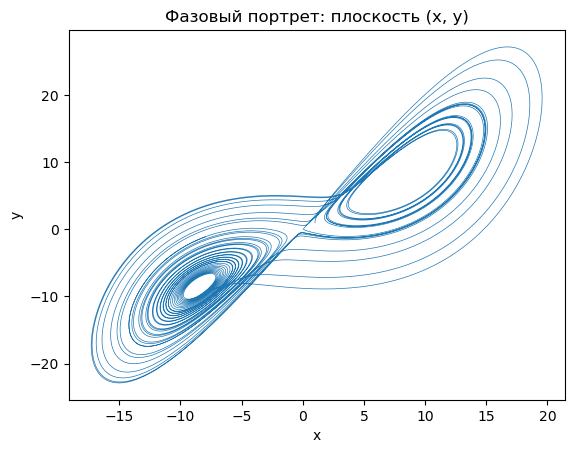

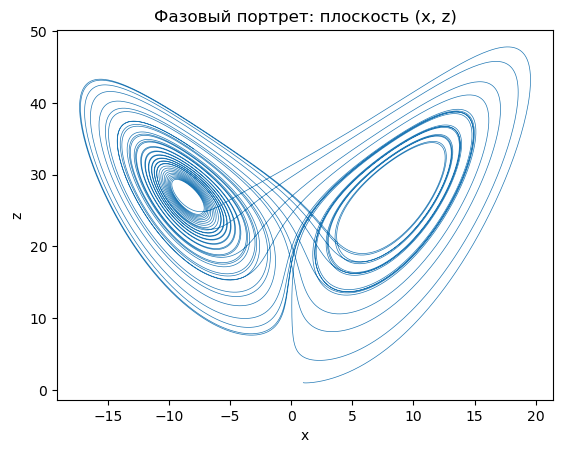

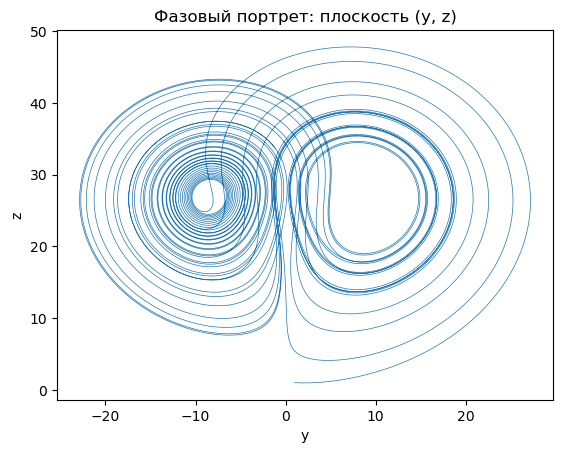

In [4]:

# Фазовые портреты
plt.figure()
plt.plot(x, y, linewidth=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Фазовый портрет: плоскость (x, y)")
plt.show()

plt.figure()
plt.plot(x, z, linewidth=0.5)
plt.xlabel("x")
plt.ylabel("z")
plt.title("Фазовый портрет: плоскость (x, z)")
plt.show()

plt.figure()
plt.plot(y, z, linewidth=0.5)
plt.xlabel("y")
plt.ylabel("z")
plt.title("Фазовый портрет: плоскость (y, z)")
plt.show()


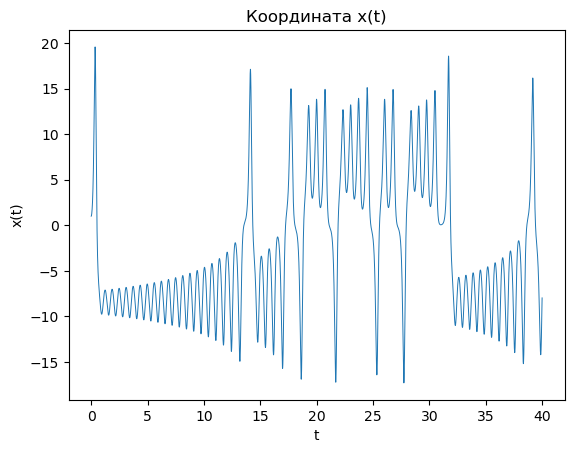

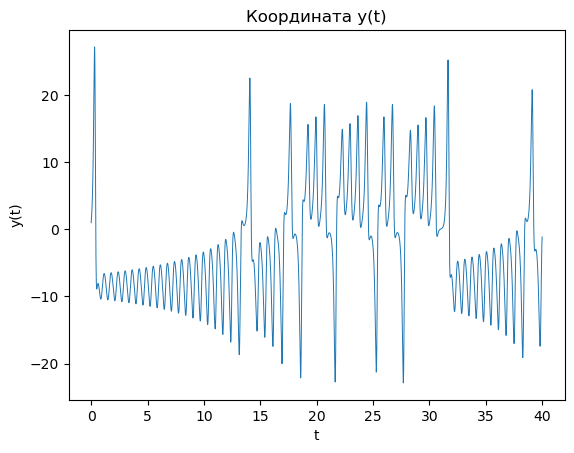

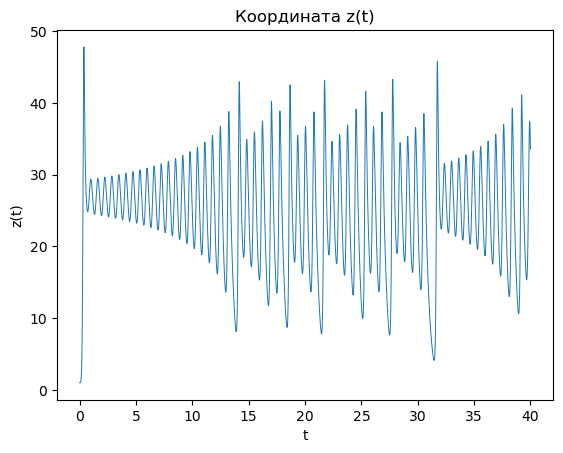

In [5]:

# Временные ряды координат — отдельные графики
plt.figure()
plt.plot(t, x, linewidth=0.7)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Координата x(t)")
plt.show()

plt.figure()
plt.plot(t, y, linewidth=0.7)
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Координата y(t)")
plt.show()

plt.figure()
plt.plot(t, z, linewidth=0.7)
plt.xlabel("t")
plt.ylabel("z(t)")
plt.title("Координата z(t)")
plt.show()


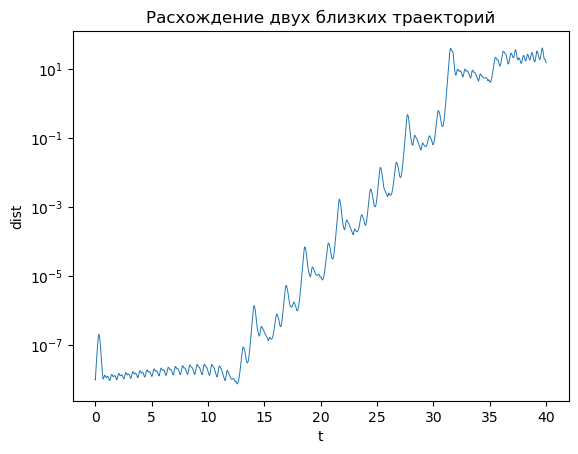

In [6]:
# Чувствительность к начальным условиям
eps = 1e-8
y0_pert = [y0[0] + eps, y0[1], y0[2]]

sol2 = solve_ivp(lorenz, (t0, t1), y0_pert, t_eval=t_eval, rtol=1e-9, atol=1e-12)
x2, y2, z2 = sol2.y

# норма
dist = np.sqrt((x2 - x)**2 + (y2 - y)**2 + (z2 - z)**2)
#dist = dist/eps #отнормировал расстояние

plt.figure()
plt.plot(t, dist, linewidth=0.7)
plt.xlabel("t")
plt.ylabel("dist")
plt.title("Расхождение двух близких траекторий")
plt.yscale("log")  # лог-масштаб\
plt.show()



## Аттрактор при разных значениях rho

Здесь варьируем параметр rho и для каждого значения интегрируем систему,
затем рисуем 2D-проекцию траектории после отбрасывания переходного участка.


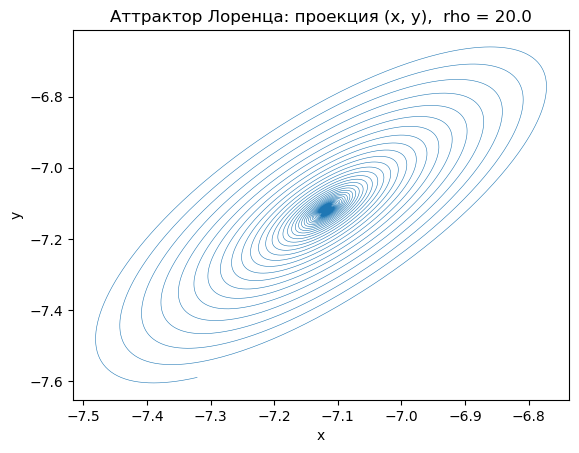

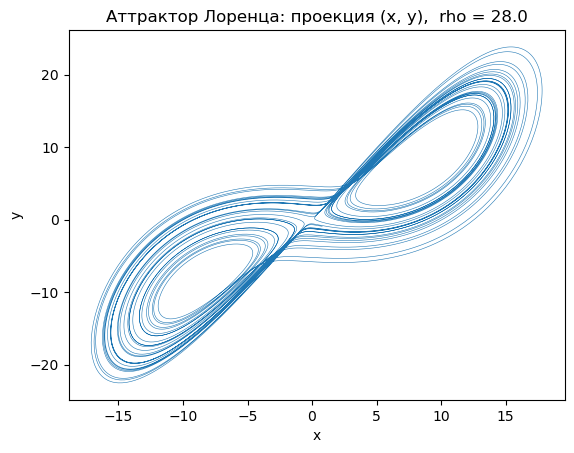

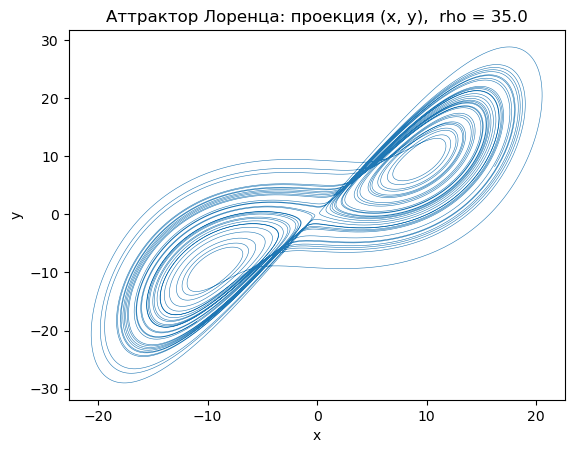

In [7]:

def integrate_lorenz(rho_value, y0, t0=0.0, t1=60.0, n_points=20000, rtol=1e-8, atol=1e-11):
    # Интегрирует Лоренца на [t0, t1] с данным rho_value и возвращает t, x, y, z.
    from scipy.integrate import solve_ivp
    t_eval = np.linspace(t0, t1, n_points)
    def f(t, s):
        return lorenz(t, s, sigma=sigma, rho=rho_value, beta=beta)
    sol = solve_ivp(f, (t0, t1), y0, t_eval=t_eval, rtol=rtol, atol=atol)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

# Примеры значений rho: регулярный режим, хаос и др.
rho_list = [20.0, 28.0, 35.0]

for rho_val in rho_list:
    tA, xA, yA, zA = integrate_lorenz(rho_val, y0=[1.0, 1.0, 1.0], t1=60.0, n_points=30000)
    # Отбросим переходной участок (например, первые 30% времени)
    cut = int(0.3 * len(tA))
    plt.figure()
    plt.plot(xA[cut:], yA[cut:], linewidth=0.4)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Аттрактор Лоренца: проекция (x, y),  rho = {rho_val}")
    plt.show()



## Бифуркационная диаграмма по rho (по локальным максимумам z)

Для каждого rho интегрируем систему, извлекаем локальные максимумы (z(t)) после переходного участка
и рисуем точки (rho, z_max). Периодические режимы дают конечное число «веток» на каждом rho,
хаотические — «полосы» плотных значений.


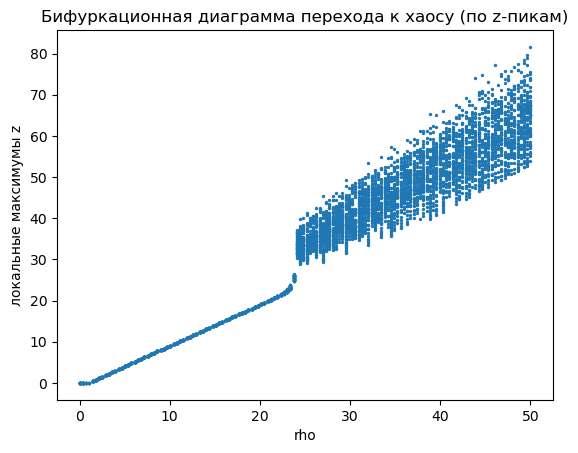

In [8]:

def local_maxima(t, z, drop_frac=0.4):
    # Находит локальные максимумы z(t) после отбрасывания доли drop_frac начальных данных.
    n = len(z)
    start = int(drop_frac * n)
    z_mid = z[1:-1]
    peaks_mask = (z_mid > z[:-2]) & (z_mid > z[2:])
    idx = np.where(peaks_mask)[0] + 1
    idx = idx[idx >= start]
    return t[idx], z[idx]

# Диапазон значений rho и вычисление диаграммы
rhos = np.linspace(0.0, 50.0, 140)
R_vals = []
Zmax_vals = []

for r in rhos:
    tB, xB, yB, zB = integrate_lorenz(r, y0=[1.0, 1.0, 1.0], t1=80.0, n_points=20000, rtol=1e-7, atol=1e-10)
    _, z_peaks = local_maxima(tB, zB, drop_frac=0.5)
    if len(z_peaks) > 0:
        keep = z_peaks[-50:]
        R_vals.extend([r]*len(keep))
        Zmax_vals.extend(keep.tolist())

plt.figure()
plt.scatter(R_vals, Zmax_vals, s=2)
plt.xlabel("rho")
plt.ylabel("локальные максимумы z")
plt.title("Бифуркационная диаграмма перехода к хаосу (по z-пикам)")
plt.show()



## Сечения Пуанкаре

Будем строить точки пересечения траекторий с плоскостью \(x=0\) при переходе слева направо (направление \(+1\)).
Для пересечений возьмём координаты \((y,z)\). В регулярных режимах получаются конечные наборы точек,
в хаотическом — «облака» точек.


In [9]:

from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

def poincare_section_x0_fixed(rho_value, y0, t0=0.0, t1=180.0, max_step=0.05,
                              rtol=1e-8, atol=1e-11, drop_frac=0.3, keep=None,
                              select_dir=+1):
    """
    Сечение Пуанкаре по плоскости x=0.
    - Ловим оба направления (direction=0), затем фильтруем по знаку xdot = σ(y-x).
    - drop_frac: доля ранних событий, которые выбрасываем как переходный участок.
    - keep: если задано, оставляем только последние 'keep' событий.
    - select_dir: +1 (слева-направо), -1 (справа-налево)
    Возвращает массивы y_pts, z_pts.
    """
    def f(t, s):
        return lorenz(t, s, sigma=sigma, rho=rho_value, beta=beta)

    def x_zero(t, s):
        return s[0]  # x=0
    x_zero.direction = 0  # оба направления
    x_zero.terminal = False

    sol = solve_ivp(f, (t0, t1), y0, events=x_zero,
                    rtol=rtol, atol=atol, max_step=max_step)

    ev = sol.y_events[0] if len(sol.y_events) else np.empty((0,3))
    if ev.shape[0] == 0:
        return np.array([]), np.array([])

    # ориентация по знаку xdot = σ(y-x)
    xdot = sigma * (ev[:,1] - ev[:,0])
    if select_dir == +1:
        mask = xdot > 0
    elif select_dir == -1:
        mask = xdot < 0
    else:
        mask = np.ones(len(xdot), dtype=bool)
    ev = ev[mask]
    if ev.shape[0] == 0:
        return np.array([]), np.array([])

    # выбрасываем долю переходных событий
    cut = int(drop_frac * ev.shape[0])
    ev = ev[cut:]
    if keep is not None and ev.shape[0] > keep:
        ev = ev[-keep:]

    return ev[:,1], ev[:,2]  # y, z

def poincare_section_zconst(rho_value, y0, z0=27.0, t0=0.0, t1=180.0, max_step=0.05,
                            rtol=1e-8, atol=1e-11, drop_frac=0.3, keep=None,
                            select_dir=+1):
    """
    Сечение Пуанкаре по плоскости z = z0.
    - direction по знаку zdot = x*y - β z: выбираем +1 (снизу-вверх) или -1 (сверху-вниз).
    - Возвращаем x_pts, y_pts на этой плоскости.
    """
    def f(t, s):
        return lorenz(t, s, sigma=sigma, rho=rho_value, beta=beta)

    def z_plane(t, s):
        return s[2] - z0
    z_plane.direction = 0  # ловим оба направления
    z_plane.terminal = False

    sol = solve_ivp(f, (t0, t1), y0, events=z_plane,
                    rtol=rtol, atol=atol, max_step=max_step)

    ev = sol.y_events[0] if len(sol.y_events) else np.empty((0,3))
    if ev.shape[0] == 0:
        return np.array([]), np.array([])

    # ориентация: zdot = x*y - β z
    zdot = ev[:,0] * ev[:,1] - beta * ev[:,2]
    if select_dir == +1:
        mask = zdot > 0
    elif select_dir == -1:
        mask = zdot < 0
    else:
        mask = np.ones(len(zdot), dtype=bool)
    ev = ev[mask]
    if ev.shape[0] == 0:
        return np.array([]), np.array([])

    cut = int(drop_frac * ev.shape[0])
    ev = ev[cut:]
    if keep is not None and ev.shape[0] > keep:
        ev = ev[-keep:]

    return ev[:,0], ev[:,1]  # x, y


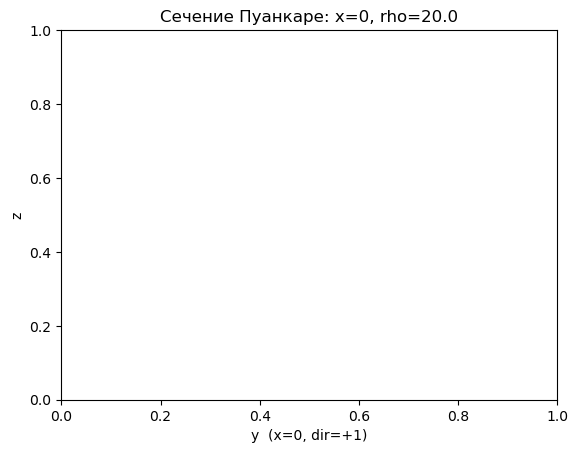

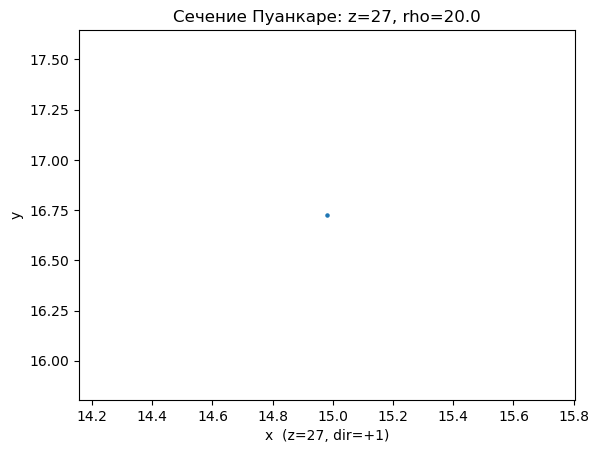

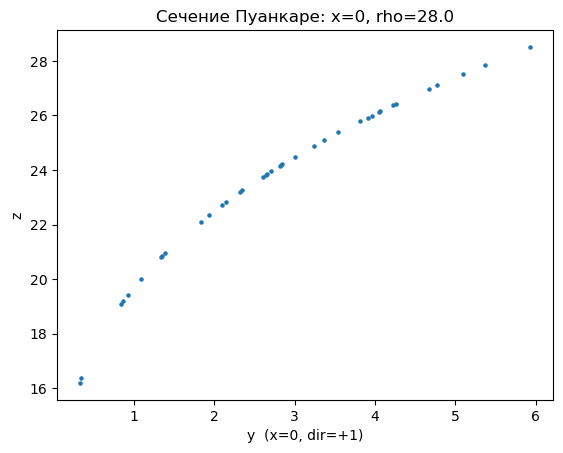

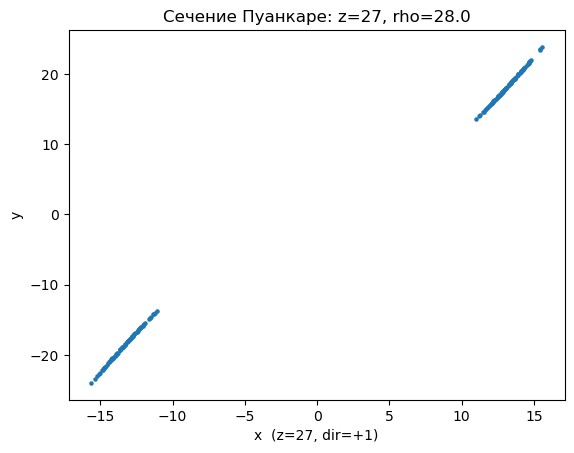

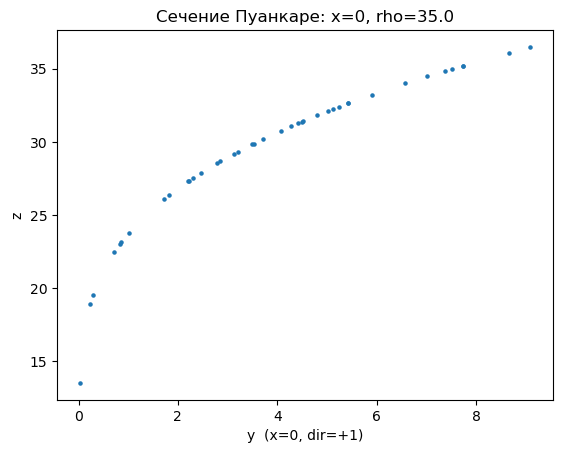

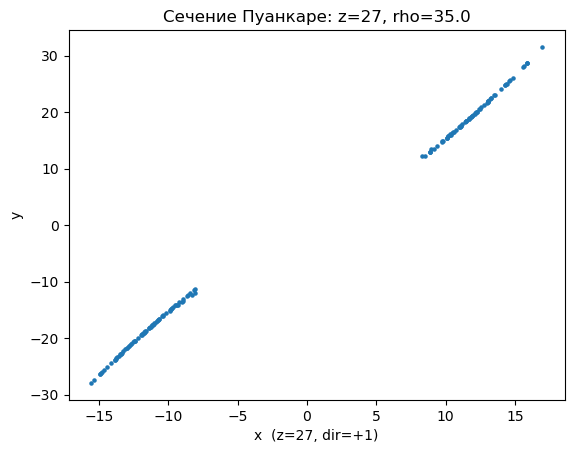

In [10]:

# Демонстрация: x=0 (dir=+1) и z=27 (dir=+1) для нескольких rho
for rho_val in [20.0, 28.0, 35.0]:
    # x = 0
    yP, zP = poincare_section_x0_fixed(rho_val, y0=[1.0, 1.0, 1.0],
                                       t1=180.0, max_step=0.05,
                                       drop_frac=0.3, keep=800,
                                       select_dir=+1)
    plt.figure()
    if len(yP):
        plt.scatter(yP, zP, s=5)
    plt.xlabel("y  (x=0, dir=+1)")
    plt.ylabel("z")
    plt.title(f"Сечение Пуанкаре: x=0, rho={rho_val}")
    plt.show()

    # z = 27
    xP, yP2 = poincare_section_zconst(rho_val, y0=[1.0, 1.0, 1.0], z0=27.0,
                                      t1=180.0, max_step=0.05,
                                      drop_frac=0.3, keep=800,
                                      select_dir=+1)
    plt.figure()
    if len(xP):
        plt.scatter(xP, yP2, s=5)
    plt.xlabel("x  (z=27, dir=+1)")
    plt.ylabel("y")
    plt.title(f"Сечение Пуанкаре: z=27, rho={rho_val}")
    plt.show()
